In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
import statsmodels.api as sm

In [4]:
df = pd.read_csv('solar_efficiency_temp.csv')

x = df[['temperature']]
y = df['efficiency']

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [8]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [9]:
y_pred = model.predict(x_test)

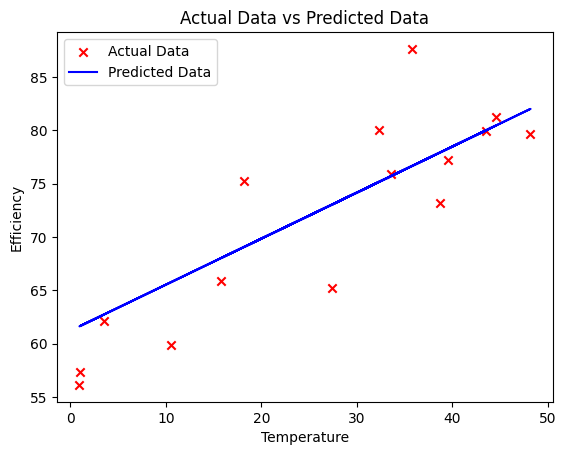

In [11]:
plt.scatter(x_test,y_test,color='r',marker='x',label='Actual Data')
plt.plot(x_test,y_pred,color = 'b',label = 'Predicted Data')
plt.title("Actual Data vs Predicted Data")
plt.xlabel("Temperature")
plt.ylabel("Efficiency")
plt.legend()
plt.show()

In [16]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse} and R2 Score: {r2}")

Mean Squared Error: 24.140316968606932 and R2 Score: 0.7345500380759138


In [17]:
x = sm.add_constant(x)

model = sm.OLS(y,x).fit()

In [19]:
t_stat = model.tvalues['temperature']
t_pvalue = model.pvalues['temperature']

f_stat = model.fvalue
f_pvalue = model.f_pvalue

print(f"F-Stattistic: {f_stat} and T-Statistic: {t_stat}")

F-Stattistic: 91.58938851225089 and T-Statistic: 9.570234506648786


In [20]:
if t_pvalue < 0.5:
    print("The regression coeefficicent for Temperature is statistically significant")
else:
    print("The regression coeefficicent for Temperature is not statistically significant")

if f_pvalue < 0.5:
    print("The temperature significantly predicts the Efficicency of the solar panels")
else:
    print("The temperature does not predicts the Efficicency of the solar panels")

The regression coeefficicent for Temperature is statistically significant
The temperature significantly predicts the Efficicency of the solar panels
